In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv("iris.csv")

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


In [6]:
df["Species"].unique()

<ArrowStringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

<Axes: xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

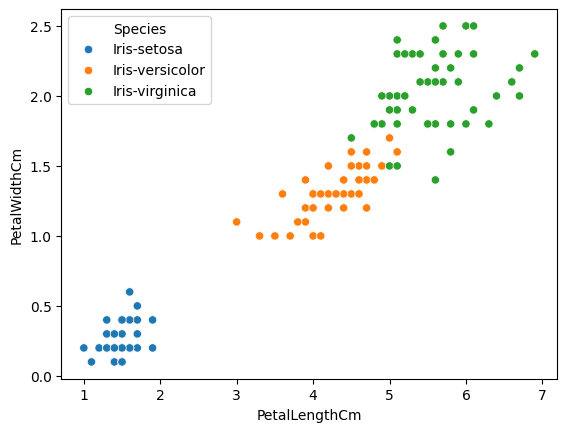

In [7]:
sns.scatterplot(x = df['PetalLengthCm'], y = df['PetalWidthCm'], hue = df['Species'])

In [8]:
df = df.drop(columns = ['Id'])

In [9]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y = df['Species'].values

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
le = LabelEncoder()

In [12]:
y = le.fit_transform(y)

In [13]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [14]:
# 0 - Iris-setosa
# 1 - Iris-versicolor
# 2 - Iris-virginica

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_text, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [17]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_text, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.long)
y_test = torch.tensor(y_test, dtype = torch.long)

In [18]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([120, 4]) torch.Size([120])
torch.Size([30, 4]) torch.Size([30])


In [19]:
from torch import nn

In [20]:
class IrisModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 4, out_features= 16)
        self.layer_2 = nn.Linear(in_features = 16, out_features= 16)
        self.layer_3 = nn.Linear(in_features = 16, out_features= 3)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        x = self.relu(x)
        x = self.layer_3(x)

        return x

In [21]:
model = IrisModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [22]:
def calculate_accuracy(y_pred, y_true):
    correct = torch.eq(y_pred, y_true).sum().item()
    acc = (correct / len(y_true)) * 100
    return acc

In [23]:
y_logits = model(X_test)

In [24]:
y_pred_probs = torch.softmax(y_logits, dim = 1)

In [25]:
epochs = 200

train_loss_values = []
train_acc_values = []
test_loss_values = []
test_acc_values = []

for epoch in range(epochs):

    model.train()

    logits = model(X_train)
    loss = loss_fn(logits, y_train)
    
    pred = torch.softmax(logits, dim = 1).argmax(dim = 1)
    acc = calculate_accuracy(y_train, pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss_values.append(loss.item())
    train_acc_values.append(acc)
    
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)

        test_pred = torch.softmax(test_logits, dim = 1).argmax(dim = 1)
        test_acc = calculate_accuracy(y_test, test_pred)

        test_loss_values.append(test_loss.item())
        test_acc_values.append(test_acc)

        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

            

Epoch: 0 | Train Loss: 1.1933 | Train Acc: 33.33% | Test Loss: 1.1362 | Test Acc: 33.33%
Epoch: 10 | Train Loss: 0.9302 | Train Acc: 57.50% | Test Loss: 0.9013 | Test Acc: 66.67%
Epoch: 20 | Train Loss: 0.6257 | Train Acc: 66.67% | Test Loss: 0.5958 | Test Acc: 66.67%
Epoch: 30 | Train Loss: 0.4276 | Train Acc: 81.67% | Test Loss: 0.4192 | Test Acc: 86.67%
Epoch: 40 | Train Loss: 0.3147 | Train Acc: 96.67% | Test Loss: 0.3130 | Test Acc: 96.67%
Epoch: 50 | Train Loss: 0.2068 | Train Acc: 96.67% | Test Loss: 0.2096 | Test Acc: 100.00%
Epoch: 60 | Train Loss: 0.1274 | Train Acc: 97.50% | Test Loss: 0.1341 | Test Acc: 100.00%
Epoch: 70 | Train Loss: 0.0887 | Train Acc: 98.33% | Test Loss: 0.0943 | Test Acc: 100.00%
Epoch: 80 | Train Loss: 0.0725 | Train Acc: 98.33% | Test Loss: 0.0743 | Test Acc: 100.00%
Epoch: 90 | Train Loss: 0.0650 | Train Acc: 98.33% | Test Loss: 0.0639 | Test Acc: 100.00%
Epoch: 100 | Train Loss: 0.0610 | Train Acc: 98.33% | Test Loss: 0.0578 | Test Acc: 100.00%
Epoc

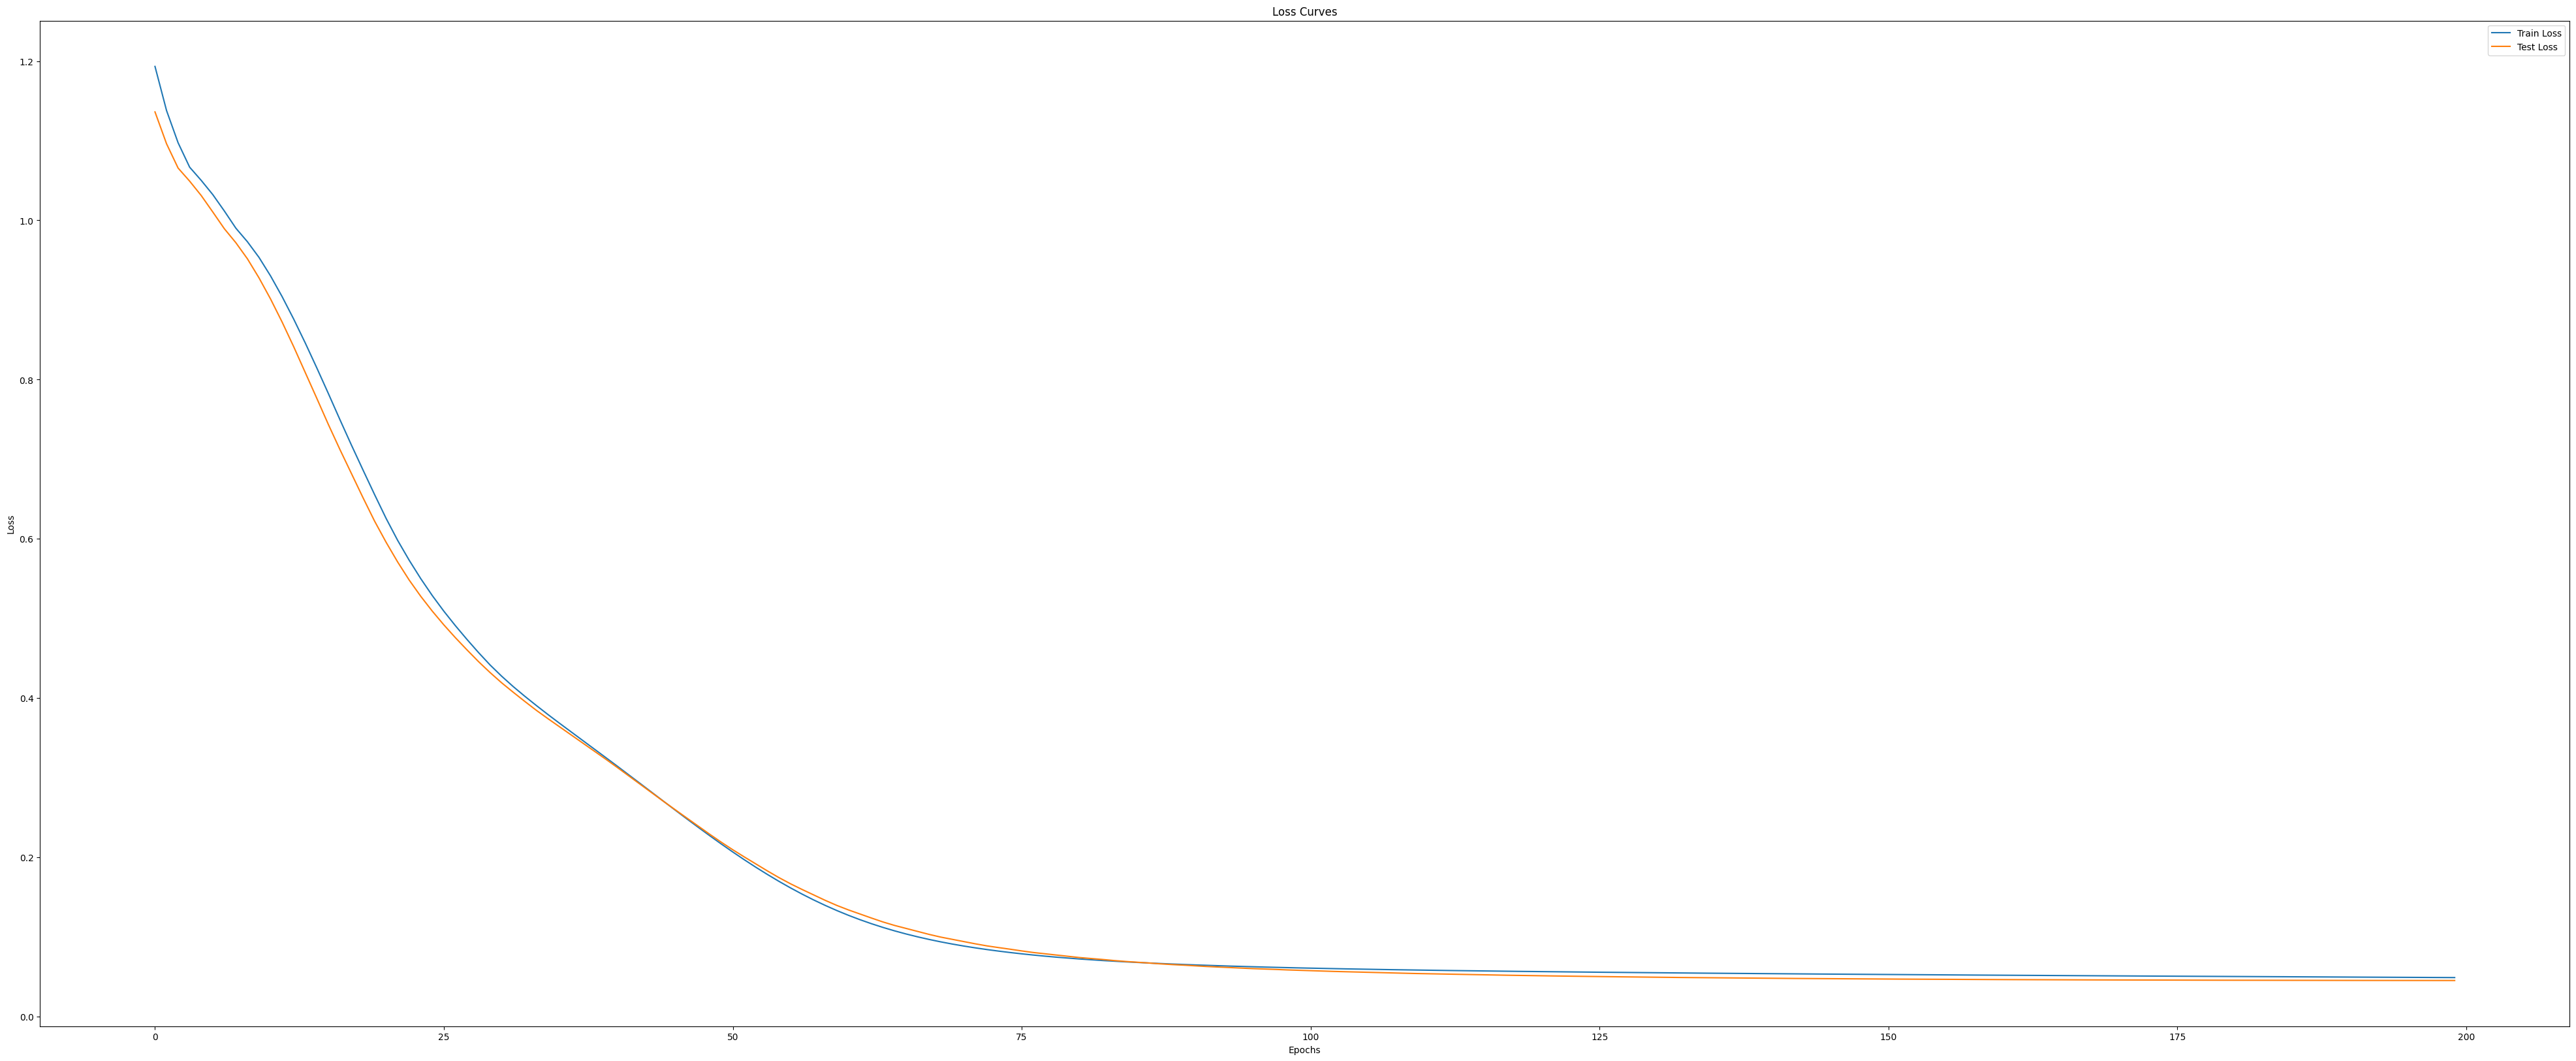

In [26]:
plt.figure(figsize = (50, 20))
plt.plot(train_loss_values, label = "Train Loss")
plt.plot(test_loss_values, label = "Test Loss")
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

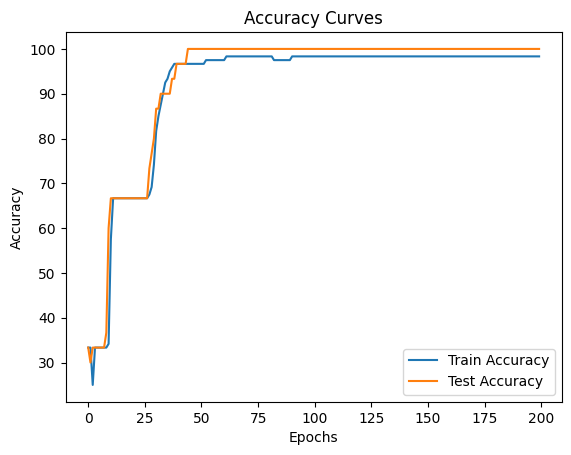

In [27]:
plt.Figure(figsize = (50, 20))
plt.plot(train_acc_values, label = "Train Accuracy")
plt.plot(test_acc_values, label = "Test Accuracy")
plt.title("Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [28]:
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])
new_sample_t = torch.tensor(new_sample, dtype = torch.float32)
model.eval()

IrisModel(
  (layer_1): Linear(in_features=4, out_features=16, bias=True)
  (layer_2): Linear(in_features=16, out_features=16, bias=True)
  (layer_3): Linear(in_features=16, out_features=3, bias=True)
  (relu): ReLU()
)

In [29]:
with torch.inference_mode():
    pred_logits = model(new_sample_t)
    pred_prob = torch.softmax(pred_logits, dim = 1)
    predicted = torch.argmax(pred_prob, dim = 1).item()

In [30]:
print(predicted)

0


In [31]:
from torchmetrics.classification import MulticlassAccuracy
accur = MulticlassAccuracy(num_classes=3)

In [32]:
epochs = 200
model2 = IrisModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr = 0.01)

for epoch in range(epochs):

    model2.train()
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.softmax(logits, dim = 1).argmax(dim = 1)
    acc = accur(pred, y_train).item() * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model2.eval()

    with torch.inference_mode():
        test_logits = model2(X_test)
        test_loss = loss_fn(test_logits, y_test)

        test_pred = torch.softmax(test_logits, dim = 1).argmax(dim = 1)
        test_acc = accur(test_pred, y_test).item() * 100

        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 1.0869 | Train Acc: 33.33% | Test Loss: 1.0297 | Test Acc: 33.33%
Epoch: 10 | Train Loss: 0.7975 | Train Acc: 66.67% | Test Loss: 0.7697 | Test Acc: 73.33%
Epoch: 20 | Train Loss: 0.5213 | Train Acc: 66.67% | Test Loss: 0.5044 | Test Acc: 73.33%
Epoch: 30 | Train Loss: 0.3590 | Train Acc: 96.67% | Test Loss: 0.3557 | Test Acc: 93.33%
Epoch: 40 | Train Loss: 0.2209 | Train Acc: 97.50% | Test Loss: 0.2243 | Test Acc: 100.00%
Epoch: 50 | Train Loss: 0.1223 | Train Acc: 97.50% | Test Loss: 0.1315 | Test Acc: 100.00%
Epoch: 60 | Train Loss: 0.0820 | Train Acc: 98.33% | Test Loss: 0.0868 | Test Acc: 100.00%
Epoch: 70 | Train Loss: 0.0670 | Train Acc: 98.33% | Test Loss: 0.0662 | Test Acc: 100.00%
Epoch: 80 | Train Loss: 0.0608 | Train Acc: 97.50% | Test Loss: 0.0556 | Test Acc: 100.00%
Epoch: 90 | Train Loss: 0.0575 | Train Acc: 97.50% | Test Loss: 0.0482 | Test Acc: 100.00%
Epoch: 100 | Train Loss: 0.0555 | Train Acc: 97.50% | Test Loss: 0.0450 | Test Acc: 100.00%
Epo

In [33]:
from torchmetrics.classification import MulticlassConfusionMatrix
cm = MulticlassConfusionMatrix(num_classes = 3)

In [34]:
matrix = cm(test_pred, y_test)
print(matrix)

tensor([[10,  0,  0],
        [ 0, 10,  0],
        [ 0,  0, 10]])


In [35]:
from pathlib import Path

In [39]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "iris_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj = model2.state_dict(), f = MODEL_SAVE_PATH)